<center>  
<img src="https://arome1004.cafe24.com/images/machine_learning/dcx01.png" width=100%>  
</center>


In [1]:
from google.colab import drive


In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks/신규가치분석

/content/drive/MyDrive/Colab Notebooks/신규가치분석


In [4]:
!pip -q install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 23.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but yo

In [4]:
import pandas as pd

In [18]:
# 데이터 불러오기
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/신규가치분석/data/리뷰.xlsx")
df.head()

# 알바몬, 노동관련 유튜브 댓글 크롤링

,review
0,내 옵션은 LG Gram 16 인 것처럼 보이지만 더 이상 어떤 모델이 좋은 모델인...
1,생산성을 위해 LG Gram Pro 17을 조정합니까? 칙칙한 느낌이 부족합니다 ....
2,나는 LG Gram Pro 17 32GB Ultra 7을 가지고 있습니다. 팬을 높...
3,LG Gram Pro 16z90ts.g.au89a1의 정리 설치를 수행하십시오
4,방금 LG Gram Pro 16z90ts.g.au89a1을 받았습니다


## 1. 데이터 전처리
- 1.1 특수문자 제거
- 1.2 의미없는 짧은 글 제거

### 1.1 특수문자 제거
- 정규표현식(Regular Expression) 활용


In [19]:
import re

pattern = r'[^a-zA-Z0-9가-힣\s\.\?\!]'
# r : Raw String(원시문자열), 정규 표현식 패턴 잡을 때 주로 활용
# 일반 문자열에서는 '/n'이 개행을 의미해서, 문자 그대로 '\n'을 표현하려면, '\\n'처럼 이스케이프해야함
# r을 사용하면 백슬래시(원화표시)를 이스케이프할 필요 없이 \n을 그대로 사용 가능함

# 알파벳, 숫자, 한글문자, 공백을 제외한 패턴
# 리뷰가 길어지는 경우, 문장 구분을 위해 공백(\s),.?! 보존
# ^ : not


In [20]:
# 클리닝한 리뷰가 담길 리스트
new_reviews =[]

for review in df['review'] :
  text =re.sub(pattern,"",str(review)) # 패턴에 매칭되는 문자를 공백으로 반환
  new_reviews.append(text)

# 클리닝된 리뷰를 review_clean 컬럼으로 추가
df['review_clean'] = new_reviews
df.head()

,review,review_clean
0,내 옵션은 LG Gram 16 인 것처럼 보이지만 더 이상 어떤 모델이 좋은 모델인...,내 옵션은 LG Gram 16 인 것처럼 보이지만 더 이상 어떤 모델이 좋은 모델인...
1,생산성을 위해 LG Gram Pro 17을 조정합니까? 칙칙한 느낌이 부족합니다 ....,생산성을 위해 LG Gram Pro 17을 조정합니까? 칙칙한 느낌이 부족합니다 ....
2,나는 LG Gram Pro 17 32GB Ultra 7을 가지고 있습니다. 팬을 높...,나는 LG Gram Pro 17 32GB Ultra 7을 가지고 있습니다. 팬을 높...
3,LG Gram Pro 16z90ts.g.au89a1의 정리 설치를 수행하십시오,LG Gram Pro 16z90ts.g.au89a1의 정리 설치를 수행하십시오
4,방금 LG Gram Pro 16z90ts.g.au89a1을 받았습니다,방금 LG Gram Pro 16z90ts.g.au89a1을 받았습니다


### 1.2 의미없는 짧은 글 제거

In [21]:
drop_indices = [] # 삭제할 행의 인덱스를 담을 리스트

for i, review in enumerate(df['review_clean']) :
  if len(review) < 10 : #리뷰 길이가 10 미만인 경우 해당 인덱스 번호를 추가
    drop_indices.append(i)

In [22]:
len(drop_indices)

303

In [23]:
# 길이 10미만 리뷰 삭제
df.drop(drop_indices, inplace=True)

## 2. 형태소 분리
- 2.1 형태소 분리, 어간 추출, 정규화, 원하는 품사만 추출, 불용어 제거
- 2.2 DataFrame에 추가


### 2.1 형태소 분리, 어간 추출, 정규화, 원하는 품사만 추출, 불용어 제거

In [24]:
# 불용어 사전 로드
stopwords_df = pd.read_csv('data/ko-stopwords.csv')
stopwords_df

,stopwords
0,가
1,가까스로
2,가령
3,각
4,각각
...,...
594,힘입어
595,하다
596,이다
597,되다


In [25]:
# list 형변환(불용어 제거에 활용하기 위함)
stopwords_list = list(stopwords_df['stopwords'])
stopwords_list[:5]

['가', '가까스로', '가령', '각', '각각']

In [26]:
!pip install konlpy

In [27]:
from konlpy.tag import Okt
okt = Okt()

In [28]:
# 형태소 분리/어간 추출/정규화/희망 품사/불용어 제거하는 기능 정의
def pos_tagging(text):
  # 품사 태깅 + 어간 추출 + 정규화 + 형태소 분리 -> okt
  pos_words = okt.pos(text, stem = True, norm = True)

  tagged_list = [] # 결과 저장 리스트

  # pos_words = (단어, 품사)
  for word, tag in pos_words:
    if tag in ['Noun',"Adjective", "Verb"]: # 명사, 형용사, 동사인 경우
      if word not in stopwords_list: #불용어 사전에 해당되지 않는 경우
        tagged_list.append(word)

  return tagged_list

- 1.리뷰 데이터 분석
  - 목적 : 제품에 대한 감정, 평가 파악
  - 품사 : Adjective, Verb

- 2.검색어 분석
  - 목적 : 사용자가 어떤 키워드를 검색했는지 파악
  - 품사 : Noun

- 3.SNS 트렌드 분석
  - 목적 : 유행어, 신조어 의미 추출
  - 품사 : Noun, Adverb, Exclamation, Slag
  - Slang(신조어)의 경우 별도의 신조어 사전 구축하여 추가

- 4.법률 문서 분석
  - 품사 : Noun, Number, Josa  
    
- 어떤 데이터를 어떤 목적을 가지고 분석하느냐에 따라서 품사선택이 달라질 수 있다(분석가 역량)

### 2.2 데이터프레임에 추가

In [29]:
from tqdm.auto import tqdm

In [30]:
# 각 문서에 접근하여 정제된 키워드만 추출
tagged_review = []
for review in tqdm(df['review_clean']):
  tagged = pos_tagging(review)
  tagged_review.append(tagged)

  0%|          | 0/5802 [00:00<?, ?it/s]

In [31]:
df['tagged_review'] = tagged_review

In [32]:
df.head()

,review,review_clean,tagged_review
0,내 옵션은 LG Gram 16 인 것처럼 보이지만 더 이상 어떤 모델이 좋은 모델인...,내 옵션은 LG Gram 16 인 것처럼 보이지만 더 이상 어떤 모델이 좋은 모델인...,"[내, 옵션, 인, 보이, 더, 모델, 좋다, 모델, 인지, 기억]"
1,생산성을 위해 LG Gram Pro 17을 조정합니까? 칙칙한 느낌이 부족합니다 ....,생산성을 위해 LG Gram Pro 17을 조정합니까? 칙칙한 느낌이 부족합니다 ....,"[생산, 위해, 정합, 칙칙하다, 느낌, 부족하다, 팁]"
2,나는 LG Gram Pro 17 32GB Ultra 7을 가지고 있습니다. 팬을 높...,나는 LG Gram Pro 17 32GB Ultra 7을 가지고 있습니다. 팬을 높...,"[가지, 팬, 높다, 음으로, 설정, 에너지, 절약, 기능, 끄다]"
3,LG Gram Pro 16z90ts.g.au89a1의 정리 설치를 수행하십시오,LG Gram Pro 16z90ts.g.au89a1의 정리 설치를 수행하십시오,"[정리, 설치, 수행]"
4,방금 LG Gram Pro 16z90ts.g.au89a1을 받았습니다,방금 LG Gram Pro 16z90ts.g.au89a1을 받았습니다,"[방금, 받다]"


In [33]:
import pickle

df.to_pickle('data/tagged_review.pkl')

## 3. 벡터화
- 3.1 doc2vec 준비(문서 태깅)
- 3.2 doc2vec 학습
- 3.3 문서 벡터값 DF에 추가

### doc2vec
- word2vec은 단어 하나를 하나의 vector화
  - 주요 모델 : CBOW, Skip Gram
- doc2vec은 문서 하나를 하나의 vector화
  - 주요 모델 : PV-DM model, PV-DBoW
  

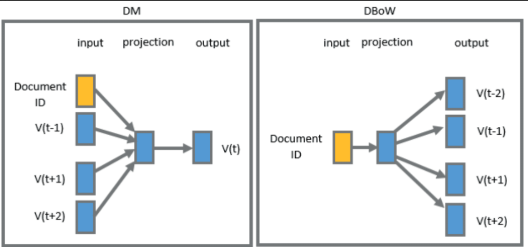

- DM : Distributed Memory
  - 벡터와 앞의 단어들을 사용해서 다음에 나오는 단어를 유추
  - 윈도우 크기 내의 단어를 input으로 사용
  - 맨 앞에서부터 한 단어씩 훈련 데이터로 사용
  - 벡터가 학습시 문서의 주제를 잡아주는 메모리와 같은 역할을 수행
  - 일반적으로 DBow보다 더 성능이 우수
- DBoW : Distributed Bag of Word
  - ID를 가지고 단어를 램덤하게 예측하는 방식

### 3.1 doc2vec 준비
- Doc2Vec 모델로 문서 벡터를 만들기 위해서는, 각 문서를 구분할 수 있는 태그(문서 ID)와 해당 문서를 구성하는 단어(토큰) 목록이 함꼐 필요함
- gensim TaggedDocument 클래스 활용

In [34]:
import gensim
# 자연어 처리, 토픽 모델링을 위한 라이브러리
from gensim.models.doc2vec import TaggedDocument # 문서 태깅 클래스

In [35]:
df['tagged_review'][1][:5]

['생산', '위해', '정합', '칙칙하다', '느낌']

In [36]:
# TaggedDocument 예시
TaggedDocument(
    tags = ['document'], # 각 문서를 구분할 수 있는 태그(문서 ID)
    words = df['tagged_review'][1] # 해당 문서를 구성하는 단어(토큰) 목록
)

# tags의 경우, 리스트로 패킹해서 여러 문서 태그를 부여할 수도 있지만,
# 보통은 문서별로 하나의 태그(예: 'document 1')만 사용하는 편이 많음

TaggedDocument(words=['생산', '위해', '정합', '칙칙하다', '느낌', '부족하다', '팁'], tags=['document'])

In [37]:
tagged_corpus_list = [] # 문서 태깅 결과를 담아둘 리스트

# 각 문서에 접근하여 문서ID 태깅
for i, tokens in enumerate(df['tagged_review']) :
  tagged_doc = TaggedDocument(tags = [f'document{i}'], words=tokens)
  tagged_corpus_list.append(tagged_doc)

In [38]:
len(tagged_corpus_list)

5802

In [39]:
from gensim.models import doc2vec

In [40]:
# 1. doc2vec 모델 초기화
model = doc2vec.Doc2Vec(
    vector_size= 100, # 학습할 벡터(임베딩)의 차원 수 (100차원)
    alpha = 0.025, # 초기 학습률(learning rate)
    min_alpha = 0.001, # 학습 진행 중에 점차 감소시킬 최소 학습률
    # 최적의 값에 수렴하기 위해 학습을 진행하면서, 학습률을 감소시킨다.
    window = 8 # 주변 단어(window) 범위 설정(앞뒤 8개 단어)

)

In [41]:
# 2. 단어 사전(vocavulary) 생성
# TaggedDocument 리스트를 토대로 전체에 등장하는 단어들을 모델에 등록
model.build_vocab(tagged_corpus_list)

In [42]:
# 모델이 인식하고 있는 문서의 총 개수
model.corpus_count

5802

In [43]:
# 3. doc2vec 모델 학습 - 문서 벡터와 단어 벡터를 기반으로 학습
model.train(
    tagged_corpus_list,
    total_examples = model.corpus_count, # 전제 문서 개수
    epochs = 5 # 학습 반복 횟수(너무 크면 과접합의 가능성/ 학습속도 느려짐)
)

In [44]:
model.dv['document0'].shape

(100,)

In [45]:
vector_list = []
for i in range(len(df)):
  doc2vec_vector = model.dv[f'document{i}'] # 각 문서 벡터에 접근
  vector_list.append(doc2vec_vector)

In [46]:
df['vector'] = vector_list

In [47]:
df.head()

,review,review_clean,tagged_review,vector
0,내 옵션은 LG Gram 16 인 것처럼 보이지만 더 이상 어떤 모델이 좋은 모델인...,내 옵션은 LG Gram 16 인 것처럼 보이지만 더 이상 어떤 모델이 좋은 모델인...,"[내, 옵션, 인, 보이, 더, 모델, 좋다, 모델, 인지, 기억]","[0.002799909, -0.020124739, -0.00073612755, 0...."
1,생산성을 위해 LG Gram Pro 17을 조정합니까? 칙칙한 느낌이 부족합니다 ....,생산성을 위해 LG Gram Pro 17을 조정합니까? 칙칙한 느낌이 부족합니다 ....,"[생산, 위해, 정합, 칙칙하다, 느낌, 부족하다, 팁]","[-0.0073174955, -0.0015292582, -0.009577336, 0..."
2,나는 LG Gram Pro 17 32GB Ultra 7을 가지고 있습니다. 팬을 높...,나는 LG Gram Pro 17 32GB Ultra 7을 가지고 있습니다. 팬을 높...,"[가지, 팬, 높다, 음으로, 설정, 에너지, 절약, 기능, 끄다]","[-0.006884969, -0.016291223, 0.013105499, -0.0..."
3,LG Gram Pro 16z90ts.g.au89a1의 정리 설치를 수행하십시오,LG Gram Pro 16z90ts.g.au89a1의 정리 설치를 수행하십시오,"[정리, 설치, 수행]","[-0.0052962736, 0.006810848, 0.004171434, 0.00..."
4,방금 LG Gram Pro 16z90ts.g.au89a1을 받았습니다,방금 LG Gram Pro 16z90ts.g.au89a1을 받았습니다,"[방금, 받다]","[-0.008517403, -0.0045046685, -0.006077687, 0...."


In [48]:
df.to_pickle('data/df_vector.pkl')

In [49]:
import pandas as pd

df = pd.read_pickle('data/df_vector.pkl')

In [50]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# dendrogram : 계층적 군집 결과(linked)를 트리 형태로 시각화
# linkage : 계층적 군집(Hierarchical Clustering)을 수행

In [51]:
# 계층적 군집 수행
linked = linkage(
    list(df['vector']), # 군집화 할 데이터 (군집 알고리즘 내에서 요구하는 입력포맷에 맞게 형변환)
    'ward' # 군집 방식 지정(여기서는 'ward' -> 군집 내 분산을 최소화)
)

# linkage : 2차원 배열형태 데이터 요구 (지금 데이터 vector가 리스트에 담겨있기 때문에 그대로 사용해도됨)

In [52]:
# df['vector']에 1068개 문서가 있다면, 계층적 군집에서 문서가 전부 하나로 합쳐질 때까지 총 1067번의 병합(=n-1)이 일어남
linked.shape

# (1067,4)
# -> 1067번의 병합 단계, 4ea의 컬럼

(5801, 4)

In [53]:
linked[0]
# -> 4ea의 컬럼[클러스터1 인덱스, 클러스터2 인덱스, 군집 간 거리, 병합된 후 새 클러스터가 포함하는 데이터 포인트 수]

array([4.10000000e+01, 5.38100000e+03, 5.93839298e-02, 2.00000000e+00])

In [54]:
df['vector'].shape

(5802,)

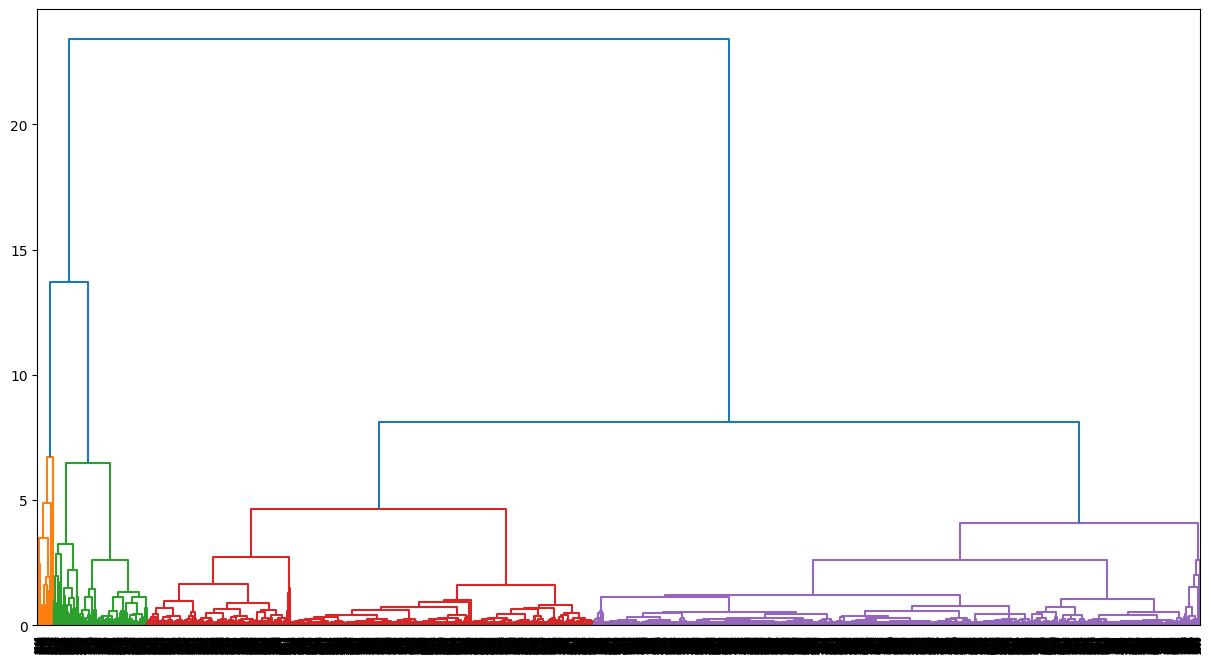

In [55]:
# 덴드로그램 시각화
plt.figure(figsize=(15,8))

dendrogram(
    linked, # 계층적 군집 결과
    orientation = 'top', # 덴드로그램의 방향(위에서 아래로 그리기(left,right,bottom))
    distance_sort = 'descending', # 클러스터 간 거리를 기준으로 내림차순 정렬
    show_leaf_counts = True, # 리프 노드(최종 말단)마다 샘플 개수 표시 여부
    color_threshold = 8 # y축 기준 -> 8 이상은 동일 색상(군집)으로 묶이지 않도록 설정
)

plt.show()

# y축 값이 낮은 지점에서 클러스터링 된 문서들은 서로 비슷한 내용일 가능성이 높음
# y축 값이 높은 곳에서 합쳐지는 문서들은 거리가 멀었다가 뒤늦게 합쳐진 것이므로, 서로 상이한 주제를 가질 수 있음

# 덴드로그램에서 threshold를 기준으로 크게 2개의 군집으로 나뉨
# 약 8 지점에서 자르면 2개 큰 군집으로 나누어지고, 더 아래로 자르면 3~4개 이상의 세부 군집으로 나눠볼 수는 있음(분석가의 몫)

In [56]:
from sklearn.cluster import AgglomerativeClustering # 병합 군집
from sklearn.metrics.cluster import silhouette_score # 실루엣 계수 평균값 계산 도구

In [57]:
#1. 클러스터 초기화
cluster = AgglomerativeClustering(n_clusters=2, linkage='ward')

In [58]:
#2. 클러스터링
cluster_label = cluster.fit_predict(list(df['vector'])) # 군집 알고리즘에서 요구하는 입력포맷에 맞게 형변환

In [59]:
# 3. 평균 실루엣 지수 계산
silhouette_avg = silhouette_score(list(df['vector']),cluster_label) # 문서 벡터, 클러스터 라벨
silhouette_avg
# -1 ~ 1 사이의 값, 1에 가까울수록 잘 군집하였다고 판단

0.71640843

In [129]:
# 각 클러스터별 평균 실루엣 지수 확인

n_clusters = range(2,10) # 클러스터 범위
scores = [] # 각 클러스터 별 실루엣 지수를 담아둘 리스트

for n in n_clusters:
  cluster = AgglomerativeClustering(n_clusters = n, linkage = 'ward') #1. 클러스트 초기화
  cluster_label = cluster.fit_predict(list(df['vector'])) #2. 클러스터링
  silhouette_avg = silhouette_score(list(df['vector']), cluster_label) #3. 평균 실루엣 지수 계산

  scores.append(silhouette_avg)

In [130]:
scores

[0.71640843,
 0.67197186,
 0.27139956,
 0.272801,
 0.27386653,
 0.27469376,
 0.1914083,
 0.20510697]

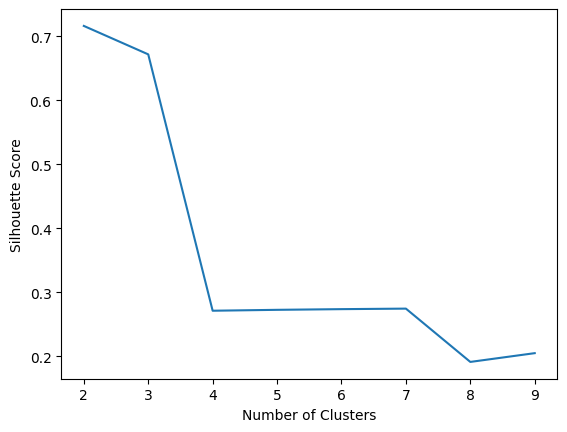

In [131]:
# 각 클러스터별 평균 실루엣 지수 시각화
plt.plot(n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [132]:
# 실루엣 지수 (silhouette score) 시각화 수행해주는 사용자 정의 함수
from shrd.plot.silhouette_plot import visualize_silhouette

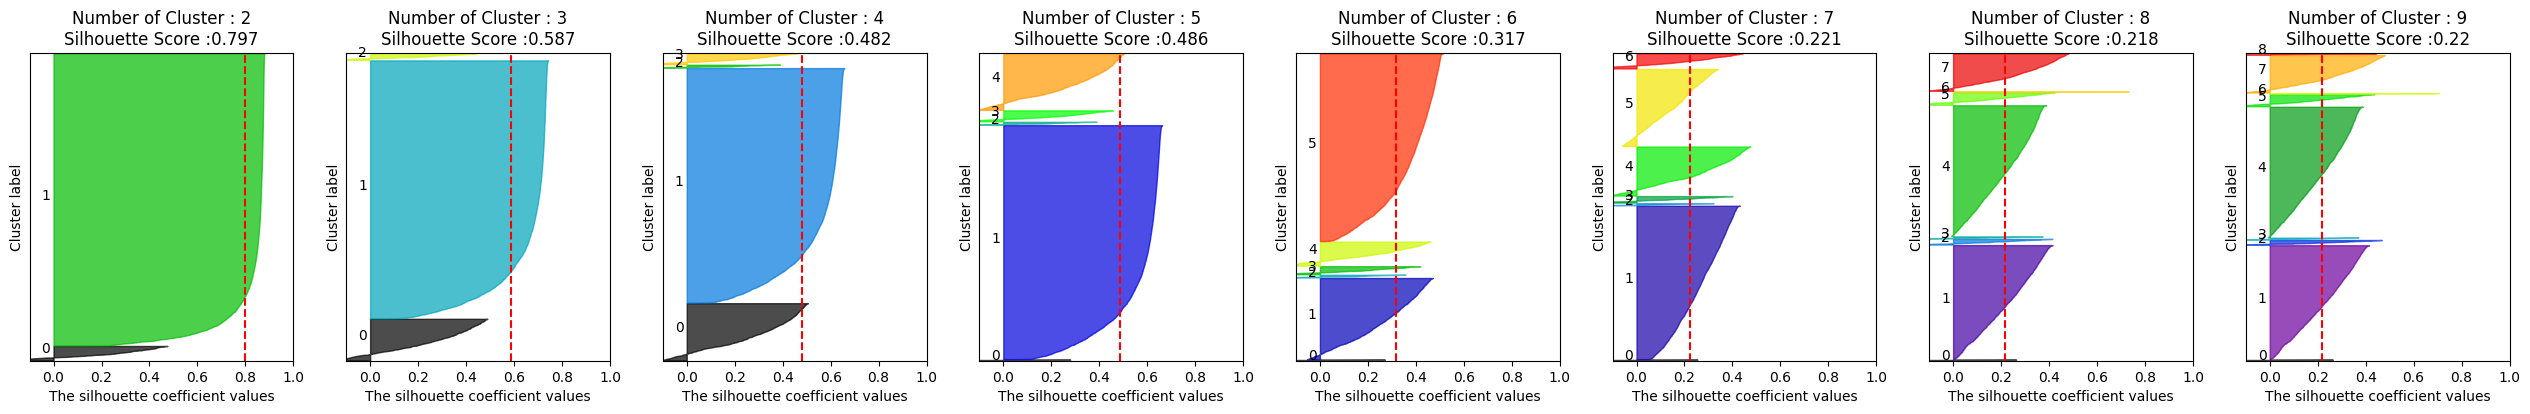

In [133]:
visualize_silhouette(n_clusters, list(df['vector'])) #클러스터 범위, 군집 분석 대상

# 군집 성능 우수 조건
# - 평균 실루엣 지수 높은 편 (높다고 좋은 것은 아님)
# - 군집별 데이터의 개수 유사
# - 음수값이 적은 것

In [134]:
# 최적의 군집수를 3으로 선정 - 분석가의 몫에 따라 변동 가능
cluster = AgglomerativeClustering(n_clusters=3, linkage = 'ward')
cluster_label = cluster.fit_predict(list(df['vector']))

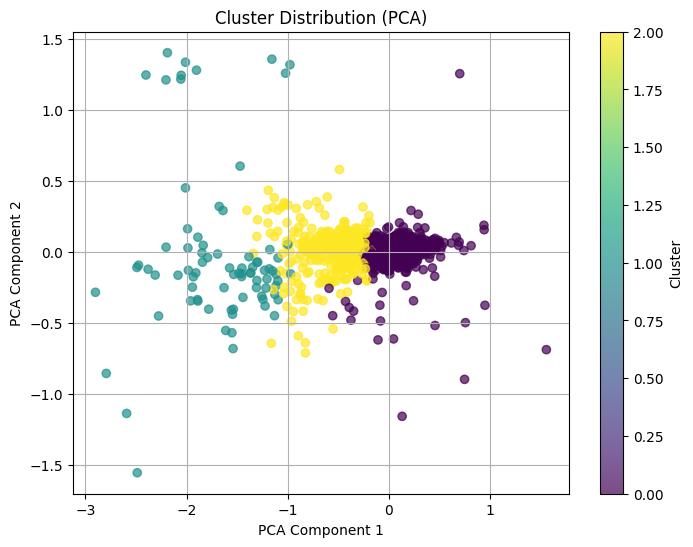

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 벡터 및 군집 결과 준비
vectors = list(df['vector'])
labels = cluster.fit_predict(vectors)  # cluster는 이미 정의된 AgglomerativeClustering 객체

# 차원 축소 (2D)
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.title("Cluster Distribution (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()



In [109]:
# 추가
df['cluster'] = cluster_label

In [110]:
df.head()

,review,review_clean,tagged_review,vector,cluster
0,내 옵션은 LG Gram 16 인 것처럼 보이지만 더 이상 어떤 모델이 좋은 모델인...,내 옵션은 LG Gram 16 인 것처럼 보이지만 더 이상 어떤 모델이 좋은 모델인...,"[내, 옵션, 인, 보이, 더, 모델, 좋다, 모델, 인지, 기억]","[0.002799909, -0.020124739, -0.00073612755, 0....",1
1,생산성을 위해 LG Gram Pro 17을 조정합니까? 칙칙한 느낌이 부족합니다 ....,생산성을 위해 LG Gram Pro 17을 조정합니까? 칙칙한 느낌이 부족합니다 ....,"[생산, 위해, 정합, 칙칙하다, 느낌, 부족하다, 팁]","[-0.0073174955, -0.0015292582, -0.009577336, 0...",1
2,나는 LG Gram Pro 17 32GB Ultra 7을 가지고 있습니다. 팬을 높...,나는 LG Gram Pro 17 32GB Ultra 7을 가지고 있습니다. 팬을 높...,"[가지, 팬, 높다, 음으로, 설정, 에너지, 절약, 기능, 끄다]","[-0.006884969, -0.016291223, 0.013105499, -0.0...",1
3,LG Gram Pro 16z90ts.g.au89a1의 정리 설치를 수행하십시오,LG Gram Pro 16z90ts.g.au89a1의 정리 설치를 수행하십시오,"[정리, 설치, 수행]","[-0.0052962736, 0.006810848, 0.004171434, 0.00...",1
4,방금 LG Gram Pro 16z90ts.g.au89a1을 받았습니다,방금 LG Gram Pro 16z90ts.g.au89a1을 받았습니다,"[방금, 받다]","[-0.008517403, -0.0045046685, -0.006077687, 0....",1


In [111]:
df['cluster'].value_counts()

,count
cluster,
1,3023
0,2231
5,342
2,125
3,65
4,10
6,6


In [112]:
all_document = [] # 각 군집별 문서를 담아내기 위한 리스트

for i in df['cluster'].unique():
  # 각 클러스터를 하나의 문서로 가정
  # df에서 각 클러스터별 불리언 인덱싱 후,
  pos_tagged = df[df['cluster'] == i]['tagged_review']

  # 동일 클러스터에 있는 모든 tagged_review(키워드들)을 하나로 합치기 위한, 문자열을 담아둘 변수
  cluster_document = ''
  for pos in pos_tagged :
    doc = ' '.join(pos) # list형의 키워드들을 공백으로 join하여 하나의 문자열로 반환
    cluster_document += doc # 문자열 이어붙이기(클러스터별 문서 만들기)

  all_document.append(cluster_document) # 완성된 클러스터별 문서를 all_document에 추가

In [113]:
df.head()

,review,review_clean,tagged_review,vector,cluster
0,내 옵션은 LG Gram 16 인 것처럼 보이지만 더 이상 어떤 모델이 좋은 모델인...,내 옵션은 LG Gram 16 인 것처럼 보이지만 더 이상 어떤 모델이 좋은 모델인...,"[내, 옵션, 인, 보이, 더, 모델, 좋다, 모델, 인지, 기억]","[0.002799909, -0.020124739, -0.00073612755, 0....",1
1,생산성을 위해 LG Gram Pro 17을 조정합니까? 칙칙한 느낌이 부족합니다 ....,생산성을 위해 LG Gram Pro 17을 조정합니까? 칙칙한 느낌이 부족합니다 ....,"[생산, 위해, 정합, 칙칙하다, 느낌, 부족하다, 팁]","[-0.0073174955, -0.0015292582, -0.009577336, 0...",1
2,나는 LG Gram Pro 17 32GB Ultra 7을 가지고 있습니다. 팬을 높...,나는 LG Gram Pro 17 32GB Ultra 7을 가지고 있습니다. 팬을 높...,"[가지, 팬, 높다, 음으로, 설정, 에너지, 절약, 기능, 끄다]","[-0.006884969, -0.016291223, 0.013105499, -0.0...",1
3,LG Gram Pro 16z90ts.g.au89a1의 정리 설치를 수행하십시오,LG Gram Pro 16z90ts.g.au89a1의 정리 설치를 수행하십시오,"[정리, 설치, 수행]","[-0.0052962736, 0.006810848, 0.004171434, 0.00...",1
4,방금 LG Gram Pro 16z90ts.g.au89a1을 받았습니다,방금 LG Gram Pro 16z90ts.g.au89a1을 받았습니다,"[방금, 받다]","[-0.008517403, -0.0045046685, -0.006077687, 0....",1


In [114]:
len(all_document)

7

In [115]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer() # Tfidf 초기화
tfidf_vector = vectorizer.fit_transform(all_document) # Tfidf 벡터화 (단어사전 만들기 + 수치화)

In [116]:
# 단어사전에 채택된 단어 목록
feature_names = vectorizer.get_feature_names_out()
feature_names

array(['가가', '가게', '가게게', ..., '힘없다', '힘주다', '힙니'], dtype=object)

In [117]:
# tfidf array 형변환
tfidf_array = tfidf_vector.toarray()
tfidf_array

array([[0.        , 0.00074055, 0.        , ..., 0.        , 0.00085297,
        0.        ],
       [0.00049195, 0.00245974, 0.00079859, ..., 0.        , 0.00056662,
        0.        ],
       [0.00102243, 0.00102243, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.00319537, 0.        , 0.        , ..., 0.00172904, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [118]:
tfidf_array.shape # 3개의 문서, 11541개의 단어사전

(7, 13758)

In [119]:
# 데이터 프레임 형변환
tfidf_df = pd.DataFrame(tfidf_array, columns = feature_names).T
tfidf_df

,0,1,2,3,4,5,6
가가,0.000000,0.000492,0.001022,0.000951,0.003195,0.000000,0.000000
가게,0.000741,0.002460,0.001022,0.000951,0.000000,0.000000,0.000000
가게게,0.000000,0.000799,0.000000,0.000000,0.000000,0.000000,0.000000
가격,0.070025,0.081656,0.091115,0.062123,0.052894,0.049702,0.042266
가격들다,0.000000,0.000799,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...
힘세대,0.000000,0.000000,0.000000,0.001544,0.000000,0.000000,0.000000
힘쓰다,0.000000,0.000000,0.000000,0.001544,0.000000,0.000000,0.000000
힘없다,0.000000,0.000000,0.000000,0.000000,0.001729,0.000000,0.000000
힘주다,0.000853,0.000567,0.000000,0.001096,0.000000,0.000000,0.000000


In [120]:
for column in tfidf_df.columns :# 클러스터 개수(컬럼개수)만큼 반복

# 각 클러스터별 TF-IDF Series를 내림차순으로 정렬
  clustering_tfidf = tfidf_df[column].sort_values(ascending=False)

# Series를 DataFrame으로 변환
  clustering_tfidf = clustering_tfidf.reset_index()
  clustering_tfidf.columns = ['word','tfidf'] # 컬럼명 명시

# 각 클러스터별 결과 csv로 저장
  clustering_tfidf.to_csv(f'data/Cluster{column}_TFIDF.csv', encoding='UTF-8', index=False)

In [121]:
cluster_0_df = pd.read_csv('data/Cluster0_TFIDF.csv')
cluster_1_df = pd.read_csv('data/Cluster1_TFIDF.csv')
cluster_2_df = pd.read_csv('data/Cluster2_TFIDF.csv')
cluster_3_df = pd.read_csv('data/Cluster3_TFIDF.csv')
cluster_4_df = pd.read_csv('data/Cluster4_TFIDF.csv')
cluster_5_df = pd.read_csv('data/Cluster5_TFIDF.csv')
cluster_6_df = pd.read_csv('data/Cluster6_TFIDF.csv')

In [ ]:
#2. 각 키워드 포함된 실제 리뷰(review 컬럼) 출력
for keyword in top30_keywords:
  print(f"====키워드 : {keyword} ====== ")

  # review_clean 컬럼을 기준으로 키워드가 포함된 원본 데이터 필터링
  filtered_reviews = df[df['review_clean'].str.contains(keyword, case=False)]
  # case : 대소문자 구분, str : DataFrame 문자열과 관련된 함수를 다루는 모듈

  # 리뷰데이터가 없는 경우를 가정
  if filtered_reviews.empty :
    print('해당 키워드가 포함된 리뷰가 없습니다.\n')

  else :
    # 실제 리뷰(review 컬럼)를 중복 제거 후 최대 3개만 출력
    unique_reviews = filtered_reviews['review'].drop_duplicates().head(3)
    for i, review in enumerate(unique_reviews, 1):
      print(f"[{i}] {review}")
    print('\n')

['문제', '노트북', '그램', '좋다', '사용', '않다', '없다', '가다', '보다', '구매', '성능', '게임', '자다', '가볍다', '프로', '인치', '되어다', '늘다', '오다', '배터리', '때문', '아니다', '생각', '설치', '비교', '다시', '많다', '들다', '그것', '모든']


In [ ]:
#2. 각 키워드 포함된 실제 리뷰(review 컬럼) 출력
for keyword in top30_keywords_2:
  print(f"====키워드 : {keyword} ====== ")

  # review_clean 컬럼을 기준으로 키워드가 포함된 원본 데이터 필터링
  filtered_reviews_2 = df[df['review_clean'].str.contains(keyword, case=False)]
  # case : 대소문자 구분, str : DataFrame 문자열과 관련된 함수를 다루는 모듈

  # 리뷰데이터가 없는 경우를 가정
  if filtered_reviews_2.empty :
    print('해당 키워드가 포함된 리뷰가 없습니다.\n')

  else :
    # 실제 리뷰(review 컬럼)를 중복 제거 후 최대 3개만 출력
    unique_reviews = filtered_reviews_2['review'].drop_duplicates().head(3)
    for i, review in enumerate(unique_reviews, 1):
      print(f"[{i}] {review}")
    print('\n')

['문제', '노트북', '그램', '좋다', '사용', '않다', '없다', '가다', '보다', '구매', '성능', '게임', '자다', '가볍다', '프로', '인치', '되어다', '늘다', '오다', '배터리', '때문', '아니다', '생각', '설치', '비교', '다시', '많다', '들다', '그것', '모든']


In [ ]:
result_list_2 = []
# 각 키워드별로 관련 리뷰 추출
for keyword in top30_keywords:
    # review_clean 기준으로 키워드 포함 여부 확인
    filtered_reviews = df[df['review_clean'].str.contains(keyword, case=False)]

    if filtered_reviews.empty:
        # 키워드만 기록 (리뷰 없음 표시)
        result_list_2.append([keyword, "해당 키워드가 포함된 리뷰가 없습니다."])
    else:
        # 중복 제거 후 최대 3개 리뷰만 저장
        unique_reviews = filtered_reviews['review'].drop_duplicates().head(3)
        for review in unique_reviews:
            result_list_2.append([keyword, review])

# 리스트 → DataFrame 변환
result_df = pd.DataFrame(result_list_2, columns=['키워드', '리뷰'])

# 엑셀 파일로 저장
result_df.to_excel('data/gram_reviews.xlsx', index=False)
print("✅ 저장 완료 : data/gram_reviews.xlsx")

['노트북', '그램', '보다', '사용', '인치', '없다', '좋다', '구매', '정도', '제품', '않다', '들다', '작업', '아니다', '크다', '프로', '가다', '되어다', '성능', '쓰다', '가볍다', '그렇다', '향상', '화면', '모델', '대비', '디자인', '발열', '온도', '생각']


In [ ]:
#2. 각 키워드 포함된 실제 리뷰(review 컬럼) 출력
for keyword in top30_keywords:
  print(f"====키워드 : {keyword} ====== ")

  # review_clean 컬럼을 기준으로 키워드가 포함된 원본 데이터 필터링
  filtered_reviews = df[df['review_clean'].str.contains(keyword, case=False)]
  # case : 대소문자 구분, str : DataFrame 문자열과 관련된 함수를 다루는 모듈

  # 리뷰데이터가 없는 경우를 가정
  if filtered_reviews.empty :
    print('해당 키워드가 포함된 리뷰가 없습니다.\n')

  else :
    # 실제 리뷰(review 컬럼)를 중복 제거 후 최대 3개만 출력
    unique_reviews = filtered_reviews['review'].drop_duplicates().head(3)
    for i, review in enumerate(unique_reviews, 1):
      print(f\"[{i}] {review}\")
    print('\\n')

Output hidden; open in https://colab.research.google.com to view.

In [136]:
#2. 각 키워드 포함된 실제 리뷰(review 컬럼) 출력
for keyword in top30_keywords_2:
  print(f"====키워드 : {keyword} ====== ")

  # review_clean 컬럼을 기준으로 키워드가 포함된 원본 데이터 필터링
  filtered_reviews_2 = df[df['review_clean'].str.contains(keyword, case=False)]
  # case : 대소문자 구분, str : DataFrame 문자열과 관련된 함수를 다루는 모듈

  # 리뷰데이터가 없는 경우를 가정
  if filtered_reviews_2.empty :
    print('해당 키워드가 포함된 리뷰가 없습니다.\n')

  else :
    # 실제 리뷰(review 컬럼)를 최대 5개 출력
    for review in filtered_reviews_2['review']:
      print(review)
    print('\n')

Output hidden; open in https://colab.research.google.com to view.

In [143]:
result_list_2 = []
# 각 키워드별로 관련 리뷰 추출
for keyword in top30_keywords:
    # review_clean 기준으로 키워드 포함 여부 확인
    filtered_reviews = df[df['review_clean'].str.contains(keyword, case=False)]

    if filtered_reviews.empty:
        # 키워드만 기록 (리뷰 없음 표시)
        result_list_2.append([keyword, "해당 키워드가 포함된 리뷰가 없습니다."])
    else:
        # 최대 5개 리뷰만 저장
        for review in filtered_reviews['review']:
            result_list_2.append([keyword, review])

# 리스트 → DataFrame 변환
result_df = pd.DataFrame(result_list_2, columns=['키워드', '리뷰'])

# 엑셀 파일로 저장
result_df.to_excel('data/gram_reviews.xlsx', index=False)
print("✅ 저장 완료 : data/gram_reviews.xlsx")

✅ 저장 완료 : data/gram_reviews.xlsx


In [144]:
result_list_2 = []
# 각 키워드별로 관련 리뷰 추출
for keyword in top30_keywords_2:
    # review_clean 기준으로 키워드 포함 여부 확인
    filtered_reviews_2 = df[df['review_clean'].str.contains(keyword, case=False)]

    if filtered_reviews_2.empty:
        # 키워드만 기록 (리뷰 없음 표시)
        result_list_2.append([keyword, "해당 키워드가 포함된 리뷰가 없습니다."])
    else:
        # 최대 5개 리뷰만 저장
        for review in filtered_reviews_2['review']:
            result_list_2.append([keyword, review])

# 리스트 → DataFrame 변환
result_df_2 = pd.DataFrame(result_list_2, columns=['키워드', '리뷰'])

# 엑셀 파일로 저장
result_df_2.to_excel('data/gram_reviews_2.xlsx', index=False)
print("✅ 저장 완료 : data/gram_reviews_2.xlsx")

✅ 저장 완료 : data/gram_reviews_2.xlsx
